# Euler-Bernoulli beam

![](euler_bernoulli_beam-light.png)
![](euler_bernoulli_beam-dark.png)

*Figure 1*: Deflection of a cantilever beam, clamped at the left end and loaded by a
distributed load, a point load, and a moment at the tip.

## Introduction

In this tutorial we solve the Euler-Bernoulli beam equation, our first *fourth-order*
problem. The strong form for a beam on the domain $\Omega = (0, L)$ reads

$$
EI \frac{\mathrm{d}^4 w}{\mathrm{d}x^4} = q,
$$

where $w$ is the transverse deflection, $EI$ the bending stiffness, and $q$ a distributed
load. We consider a cantilever: the left end is clamped,

$$
w(0) = 0, \quad w'(0) = 0,
$$

and at the right end we apply a point load $P$ and a moment $\bar{M}$.

To derive the weak form we multiply the strong form with a test function $\delta w$ and
integrate by parts *twice*:

$$
\int_0^L q \, \delta w \, \mathrm{d}x
= \int_0^L EI \, w'''' \, \delta w \, \mathrm{d}x
= \int_0^L EI \, w'' \, \delta w'' \, \mathrm{d}x
+ \left[ EI \, w''' \, \delta w - EI \, w'' \, \delta w' \right]_0^L.
$$

In the boundary term we recognize the shear force $V = -EI \, w'''$ and the bending
moment $M = EI \, w''$. At the clamped end the test functions vanish,
$\delta w(0) = \delta w'(0) = 0$, and at the tip the natural boundary conditions
prescribe $V(L) = P$ and $M(L) = \bar{M}$. The weak form thus reads: find
$w \in \mathbb{U}$ such that

$$
\int_0^L EI \, w'' \, \delta w'' \, \mathrm{d}x =
    \int_0^L q \, \delta w \, \mathrm{d}x + P \, \delta w(L) + \bar{M} \, \delta w'(L)
    \quad \forall \, \delta w \in \mathbb{T}.
$$

Two things are new compared to the second-order problems in the previous tutorials:

* The weak form contains *second* derivatives of the trial and test functions, so
  $\mathbb{U}$ and $\mathbb{T}$ are subspaces of $H^2$. Piecewise polynomials belong to
  $H^2$ only if they are $C^1$-continuous, i.e. the derivative may not jump between
  elements. Standard Lagrange interpolations are only $C^0$ and can therefore not be
  used. Instead we use the cubic `Hermite` interpolation, which has two degrees
  of freedom per node -- the deflection $w$ and the slope $w'$ -- and sharing both
  between neighboring elements gives exactly $C^1$ continuity.
* The boundary terms load not only the deflection ($P \, \delta w(L)$) but also the
  *slope* ($\bar{M} \, \delta w'(L)$). Since the slope is a degree of freedom, applying a
  point moment is as simple as adding to its entry in the force vector.

A useful property of this discretization is that the nodal deflections and slopes of
the finite element solution are *exact*, on any mesh, provided that the load term is
integrated exactly (which our quadrature rule does for the constant $q$ used here). To
make this visible we solve with only 4 elements and compare against the analytic
solution

$$
w(x) = \frac{q x^2 (x^2 - 4Lx + 6L^2)}{24 EI} + \frac{P x^2 (3L - x)}{6 EI}
     + \frac{\bar{M} x^2}{2 EI}.
$$

## Commented program

Now we solve the problem in Ferrite. What follows is a program spliced with comments.

First we load Ferrite and define the parameters (in normalized units).

In [1]:
using Ferrite

L = 1.0  # beam length
EI = 1.0 # bending stiffness
q = 1.0  # distributed load
P = 1.0  # tip point load
M̄ = 1.0; # tip moment

### Mesh
We discretize the beam with 4 `Line` elements. This is our first 1D grid: the facets of
a `Line` cell are its two end vertices, and `generate_grid` sets up the facet sets
`"left"` and `"right"` for the two end points. We use `"left"` for the clamped end
below; the tip loads need no facet set since they are applied directly to dofs.

In [2]:
grid = generate_grid(Line, (4,), Vec((0.0,)), Vec((L,)));

### Trial and test functions
We use the cubic Hermite interpolation on the reference line. It has 4 basis functions,
associated with the dofs $(w_1, w_1', w_2, w_2')$ where subscripts denote the two
vertices: `Ferrite.vertexdof_indices(ip) == ((1, 2), (3, 4))`. The slope dofs carry the
*physical* derivative $w' = \mathrm{d}w/\mathrm{d}x$.

In [3]:
ip = Hermite{RefLine, 3}();

The integrand of the stiffness contribution is a product of two second derivatives, each
linear in $\xi$, so two Gauss points integrate it exactly.

In [4]:
qr = QuadratureRule{RefLine}(2);

Since the weak form needs second derivatives of the shape functions we construct the
`CellValues` with `update_hessians = true` (they are off by default for performance) and
access them with `shape_hessian`.

In [5]:
cellvalues = CellValues(qr, ip; update_hessians = true);

### Degrees of freedom
The `DofHandler` distributes the dofs as usual; the two dofs per vertex are handled
automatically, giving $2 (n_{el} + 1) = 10$ dofs in total.

In [6]:
dh = DofHandler(grid)
add!(dh, :w, ip)
close!(dh);

> **Numbering of degrees of freedom**
>
> Recall that the numbering of degrees of freedom does not follow the numbering of the
> nodes in the grid. With Hermite there is a second pitfall: `u[i]` may be either a
> deflection *or* a slope dof.

### Boundary conditions
The clamped end requires both $w(0) = 0$ and $w'(0) = 0$. By default a `Dirichlet`
condition on a Hermite field constrains only the *deflection* dofs (prescribing a
function value to a slope dof would be wrong).

In [7]:
ch = ConstraintHandler(dh)
add!(ch, Dirichlet(:w, getfacetset(grid, "left"), (x, t) -> 0.0));

The slope dofs are constrained with a second `Dirichlet` with `kind = :derivative`, where
the function now prescribes the derivative $w'$ instead of the value:

In [8]:
add!(ch, Dirichlet(:w, getfacetset(grid, "left"), (x, t) -> 0.0; kind = :derivative))
close!(ch);

### Assembling the linear system
The element routine follows the same structure as in the
heat equation tutorial, with the stiffness
$\int EI \, \delta w'' \, w'' \, \mathrm{d}x$ now built from `shape_hessian`. In 1D the
hessian is a 1×1 tensor, so the double contraction `⊡` is just a scalar product.

In [9]:
function assemble_global!(K, f, cellvalues, dh, EI, q)
    n_basefuncs = getnbasefunctions(cellvalues)
    Ke = zeros(n_basefuncs, n_basefuncs)
    fe = zeros(n_basefuncs)
    assembler = start_assemble(K, f)
    for cell in CellIterator(dh)
        reinit!(cellvalues, cell)
        fill!(Ke, 0)
        fill!(fe, 0)
        for q_point in 1:getnquadpoints(cellvalues)
            dΩ = getdetJdV(cellvalues, q_point)
            for i in 1:n_basefuncs
                δw = shape_value(cellvalues, q_point, i)
                δw′′ = shape_hessian(cellvalues, q_point, i)
                fe[i] += q * δw * dΩ
                for j in 1:n_basefuncs
                    w′′ = shape_hessian(cellvalues, q_point, j)
                    Ke[i, j] += EI * (δw′′ ⊡ w′′) * dΩ
                end
            end
        end
        assemble!(assembler, celldofs(cell), Ke, fe)
    end
    return K, f
end

K = allocate_matrix(dh)
f = zeros(ndofs(dh))
assemble_global!(K, f, cellvalues, dh, EI, q);

### Point load and point moment
The boundary terms of the weak form become contributions to single entries of the force
vector: $P$ multiplies $\delta w(L)$, i.e. it loads the deflection dof at the tip, and
$\bar{M}$ multiplies $\delta w'(L)$, i.e. it loads the slope dof. With Lagrange elements
a point moment would require e.g. a force couple, but here it is one vector entry. The
tip dofs are local dofs 3 (deflection) and 4 (slope) of the last cell.

In [10]:
tip_dofs = celldofs(dh, getncells(grid))
f[tip_dofs[3]] += P
f[tip_dofs[4]] += M̄;

### Solution of the system

In [11]:
apply!(K, f, ch)
u = K \ f;

### Postprocessing
Since the mesh is 1D we plot the solution directly instead of exporting to VTK. To
evaluate the FE solution *inside* the elements we construct a `CellValues` with the
plotting points as "quadrature" points (the weights are unused).

In [12]:
ξs = [Vec((ξ,)) for ξ in range(-1.0, 1.0; length = 21)]
qr_plot = QuadratureRule{RefLine}(zeros(length(ξs)), ξs)
cv_plot = CellValues(qr_plot, ip; update_hessians = true, update_detJdV = false)

x_fe = Float64[]; w_fe = Float64[]; M_fe = Float64[]
for cell in CellIterator(dh)
    reinit!(cv_plot, cell)
    ue = u[celldofs(cell)]
    for q_point in 1:getnquadpoints(cv_plot)
        push!(x_fe, spatial_coordinate(cv_plot, q_point, getcoordinates(cell))[1])
        push!(w_fe, function_value(cv_plot, q_point, ue))
        push!(M_fe, EI * function_hessian(cv_plot, q_point, ue)[1, 1])
    end
end

For comparison we evaluate the analytic deflection and bending moment
$M(x) = EI \, w''(x)$:

In [13]:
w_ana(x) = (q * x^2 * (x^2 - 4L * x + 6L^2) / 24 + P * x^2 * (3L - x) / 6 + M̄ * x^2 / 2) / EI
M_ana(x) = q * (L - x)^2 / 2 + P * (L - x) + M̄;

We plot the FE deflection together with the analytic solution and mark the nodal values,
which coincide with the analytic curve even on this coarse mesh. In fact, for $q = 0$
the analytic solution is a cubic polynomial, and the FE solution would be exact
*everywhere*.

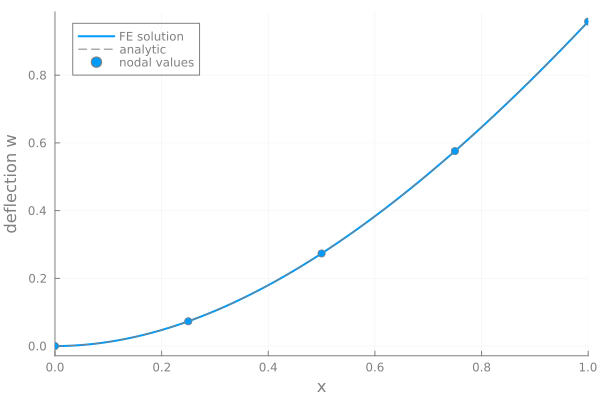

In [14]:
import Plots

node_x = range(0.0, L; length = getncells(grid) + 1)
# Transparent background and gray foreground render well on both the light and the dark
# documentation theme
theme = (background_color = :transparent, foreground_color = :gray)
plt_w = Plots.plot(x_fe, w_fe; label = "FE solution", color = 1, linewidth = 2, theme...)
Plots.plot!(plt_w, w_ana; xlims = (0, L), label = "analytic", color = :gray, linestyle = :dash)
Plots.scatter!(plt_w, node_x, evaluate_at_grid_nodes(dh, u, :w); label = "nodal values", color = 1)
Plots.plot!(plt_w; xlabel = "x", ylabel = "deflection w", legend = :topleft)

*Figure 2*: FE deflection compared to the analytic solution. The nodal values are exact.

The bending moment is obtained from the second derivative of the solution via
`function_hessian`. The FE moment is piecewise linear and only approximates the
quadratic analytic moment: derivatives of the solution converge at a lower rate than the
solution itself.

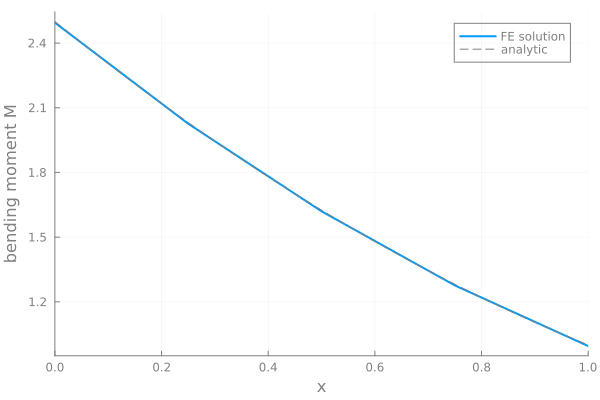

In [15]:
plt_M = Plots.plot(x_fe, M_fe; label = "FE solution", color = 1, linewidth = 2, theme...)
Plots.plot!(plt_M, M_ana; xlims = (0, L), label = "analytic", color = :gray, linestyle = :dash)
Plots.plot!(plt_M; xlabel = "x", ylabel = "bending moment M", legend = :topright)

*Figure 3*: Bending moment $M = EI \, w''$. The distributed load $q$ is the part of the
solution the cubic elements cannot represent exactly.

In [16]:
using Test                                                       #hide
@test u[tip_dofs[3]] ≈ (q * L^4 / 8 + P * L^3 / 3 + M̄ * L^2 / 2) / EI #hide
@test u[tip_dofs[4]] ≈ (q * L^3 / 6 + P * L^2 / 2 + M̄ * L) / EI      #hide
nothing                                                          #hide

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*